In [4]:
import pandas as pd

# Load metadata
metadata = pd.read_csv("../raw_data/metadata.csv")

# Quick overview
metadata.head()
metadata.info()
metadata.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file       1440 non-null   object
 1   emotion    1440 non-null   object
 2   intensity  1440 non-null   object
 3   statement  1440 non-null   object
 4   gender     1440 non-null   object
dtypes: object(5)
memory usage: 56.4+ KB


,file,emotion,intensity,statement,gender
count,1440,1440,1440,1440,1440
unique,1440,8,2,2,2
top,03-01-06-01-02-02-02.wav,fearful,normal,Dogs are sitting by the door,female
freq,1,192,768,720,720


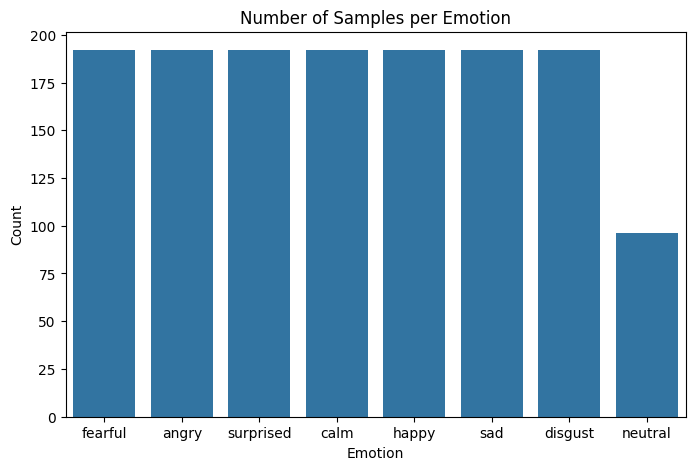

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=metadata, x='emotion', order=metadata['emotion'].value_counts().index)
plt.title("Number of Samples per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

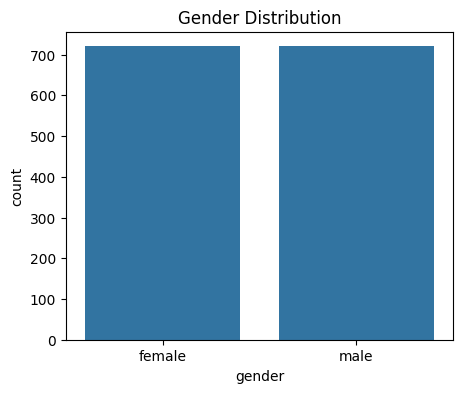

In [3]:
plt.figure(figsize=(5,4))
sns.countplot(data=metadata, x='gender')
plt.title("Gender Distribution")
plt.show()

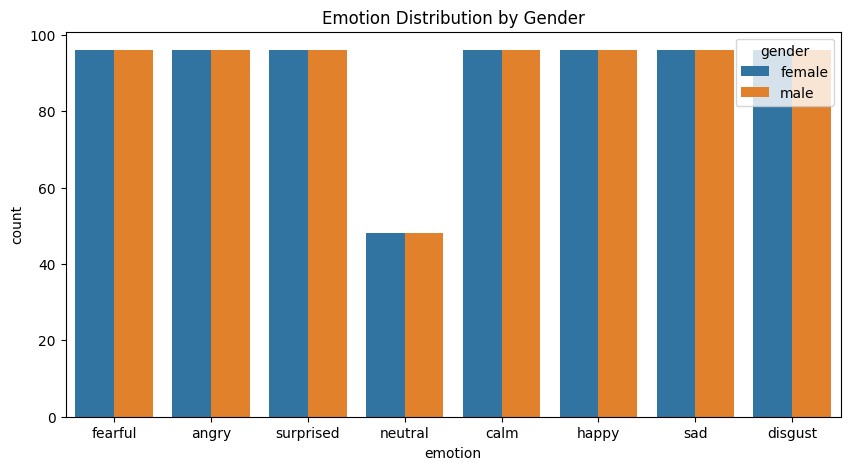

In [4]:
plt.figure(figsize=(10,5))
sns.countplot(data=metadata, x='emotion', hue='gender')
plt.title("Emotion Distribution by Gender")
plt.show()

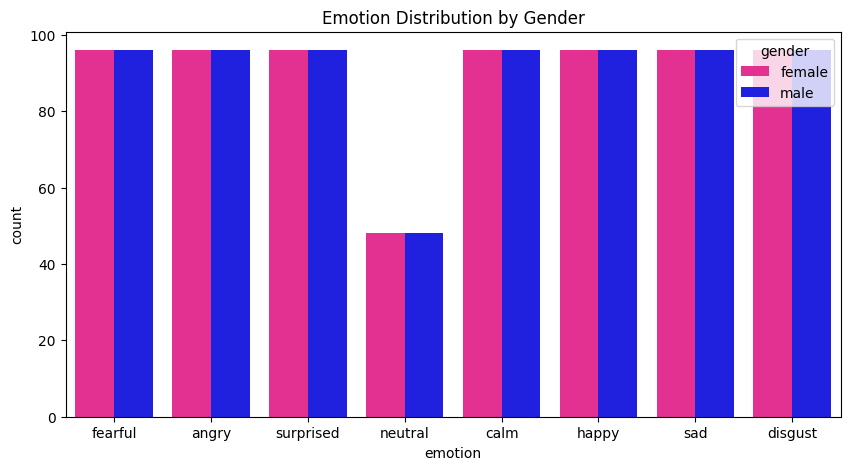

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=metadata,
    x='emotion',
    hue='gender',
    palette={'female': '#ff1493', 'male': 'blue'}  # customize colors here
)

plt.title("Emotion Distribution by Gender")
plt.show()

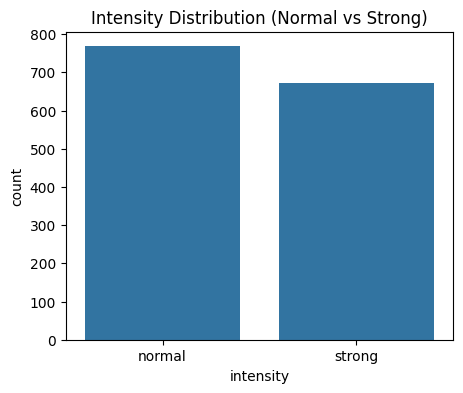

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(data=metadata, x='intensity')
plt.title("Intensity Distribution (Normal vs Strong)")
plt.show()

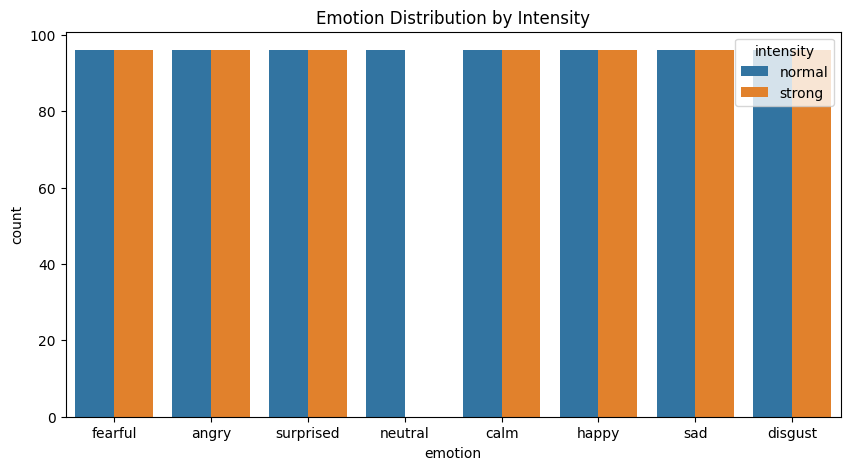

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(data=metadata, x='emotion', hue='intensity')
plt.title("Emotion Distribution by Intensity")
plt.show()

In [7]:
metadata['statement'].value_counts()

statement
Dogs are sitting by the door    720
Kids are talking by the door    720
Name: count, dtype: int64

## Metadata analysis
- Neutral is underrepresented — consider class weighting.
- All other labels are well-balanced.
- Gender, statements, and actors are evenly distributed — no bias correction needed.
- Strong intensity only applies to non-neutral emotions → keep this in mind if you use intensity as a label or feature.

---

In [8]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path().resolve().parent

audio_dir = ROOT / "raw_data" / "ravdess_audio"
metadata_file = ROOT / "raw_data" / "metadata.csv"
metadata = pd.read_csv(metadata_file) 

print(metadata.head())


                       file    emotion intensity  \
0  03-01-06-01-02-02-02.wav    fearful    normal   
1  03-01-05-01-02-01-16.wav      angry    normal   
2  03-01-08-01-01-01-14.wav  surprised    normal   
3  03-01-06-01-02-02-16.wav    fearful    normal   
4  03-01-05-01-02-01-02.wav      angry    normal   

                      statement  gender  
0  Dogs are sitting by the door  female  
1  Dogs are sitting by the door  female  
2  Kids are talking by the door  female  
3  Dogs are sitting by the door  female  
4  Dogs are sitting by the door  female  


In [9]:
# Create a dictionary: emotion -> one sample file
sample_per_emotion = {}

for emotion in metadata['emotion'].unique():
    # pick the first file for that emotion
    sample_file = metadata[metadata['emotion'] == emotion].iloc[0]['file']
    sample_per_emotion[emotion] = sample_file

sample_per_emotion

{'fearful': '03-01-06-01-02-02-02.wav',
 'angry': '03-01-05-01-02-01-16.wav',
 'surprised': '03-01-08-01-01-01-14.wav',
 'neutral': '03-01-01-01-02-02-06.wav',
 'calm': '03-01-02-01-02-01-12.wav',
 'happy': '03-01-03-01-01-02-06.wav',
 'sad': '03-01-04-01-01-02-02.wav',
 'disgust': '03-01-07-01-01-01-16.wav'}

In [10]:
import librosa
import numpy as np
import pandas as pd

rms_data = []

# Loop through one sample per emotion
for emotion, file_name in sample_per_emotion.items():
    file_path = audio_dir / file_name
    y, sr = librosa.load(file_path, sr=None)
    
    rms = librosa.feature.rms(y=y)[0]                # RMS over frames (linear)
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)  # convert to dB scale
    rms_mean = rms_db.mean()
    rms_std = rms_db.std()
    
    rms_data.append({
        'emotion': emotion,
        'rms_mean': rms_mean,
        'rms_std': rms_std,
        'rms_frames_linear': rms,   # linear amplitude
        'rms_frames_db': rms_db     # in dB
    })

rms_df = pd.DataFrame(rms_data)
rms_df

,emotion,rms_mean,rms_std,rms_frames_linear,rms_frames_db
0,fearful,-36.897293,26.798906,"[1.1324255e-05, 1.1324255e-05, 1.1324255e-05, ...","[-72.46265, -72.46265, -72.46265, -73.54283, -..."
1,angry,-42.938267,30.122847,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-78.20848, -78.20848, -78.20848, -78.20848, -..."
2,surprised,-39.052540,23.826143,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-62.999496, -62.999496, -62.999496, -62.99949..."
3,neutral,-35.630508,23.475151,"[3.090258e-06, 3.7546195e-06, 3.7546195e-06, 3...","[-62.22004, -62.22004, -62.22004, -62.22004, -..."
4,calm,-31.621204,24.769835,"[0.0, 0.0, 0.0, 0.0, 6.7434956e-07, 9.536743e-...","[-62.17625, -62.17625, -62.17625, -62.17625, -..."
5,happy,-30.932119,23.097033,"[6.2536606e-06, 8.203817e-06, 8.714517e-06, 1....","[-69.11877, -69.11877, -69.11877, -68.59654, -..."
6,sad,-40.318039,25.449015,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-67.93733, -67.93733, -67.93733, -67.93733, -..."
7,disgust,-37.203472,25.829613,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-68.10133, -68.10133, -68.10133, -68.10133, -..."


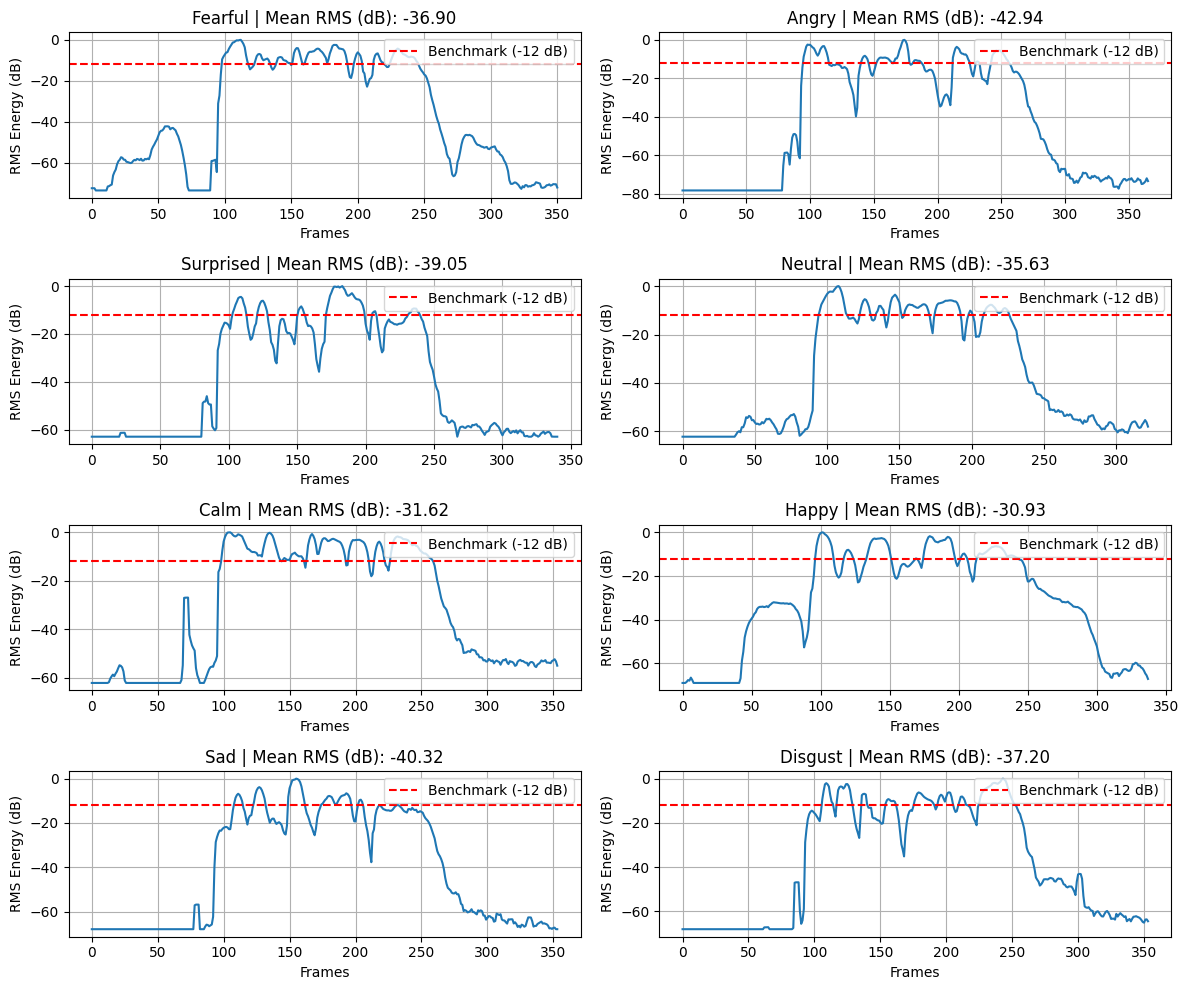

In [11]:
fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

threshold_db = -12  # horizontal reference

for i, row in rms_df.iterrows():
    axs[i].plot(row['rms_frames_db'], color='tab:blue')
    axs[i].axhline(threshold_db, color='red', linestyle='--', label=f"Benchmark ({threshold_db} dB)")
    axs[i].set_title(f"{row['emotion'].title()} | Mean RMS (dB): {row['rms_frames_db'].mean():.2f}")
    axs[i].set_xlabel("Frames")
    axs[i].set_ylabel("RMS Energy (dB)")
    axs[i].grid(True)
    axs[i].legend(loc='upper right')

plt.tight_layout()
plt.show()

## **RMS in dB (Logarithmic Loudness)**

* **dB** = logarithmic scale of amplitude:

  * 0 dB → peak amplitude in the file
  * Negative dB → quieter frames (e.g., -12 dB : Threshold of hearing)
* **RMS** measures average energy per frame

  * Linear RMS → raw amplitude
  * RMS in dB → perceptual loudness

**Reading the graph:**

* **Y-axis:** RMS energy (dB)
* **X-axis:** Frame number (~20–50 ms each)
* **Peaks** → loud syllables / intense speech
* **Valleys** → quiet vowels, consonants, or pauses
* **Benchmark line** (e.g., -12 dB) → identifies “relatively loud” frames

**Emotion patterns:**

* Angry / Fearful → higher peaks, louder
* Calm / Neutral / Sad → lower peaks, quieter
* Happy / Disgust / Surprised → intermediate energy

---


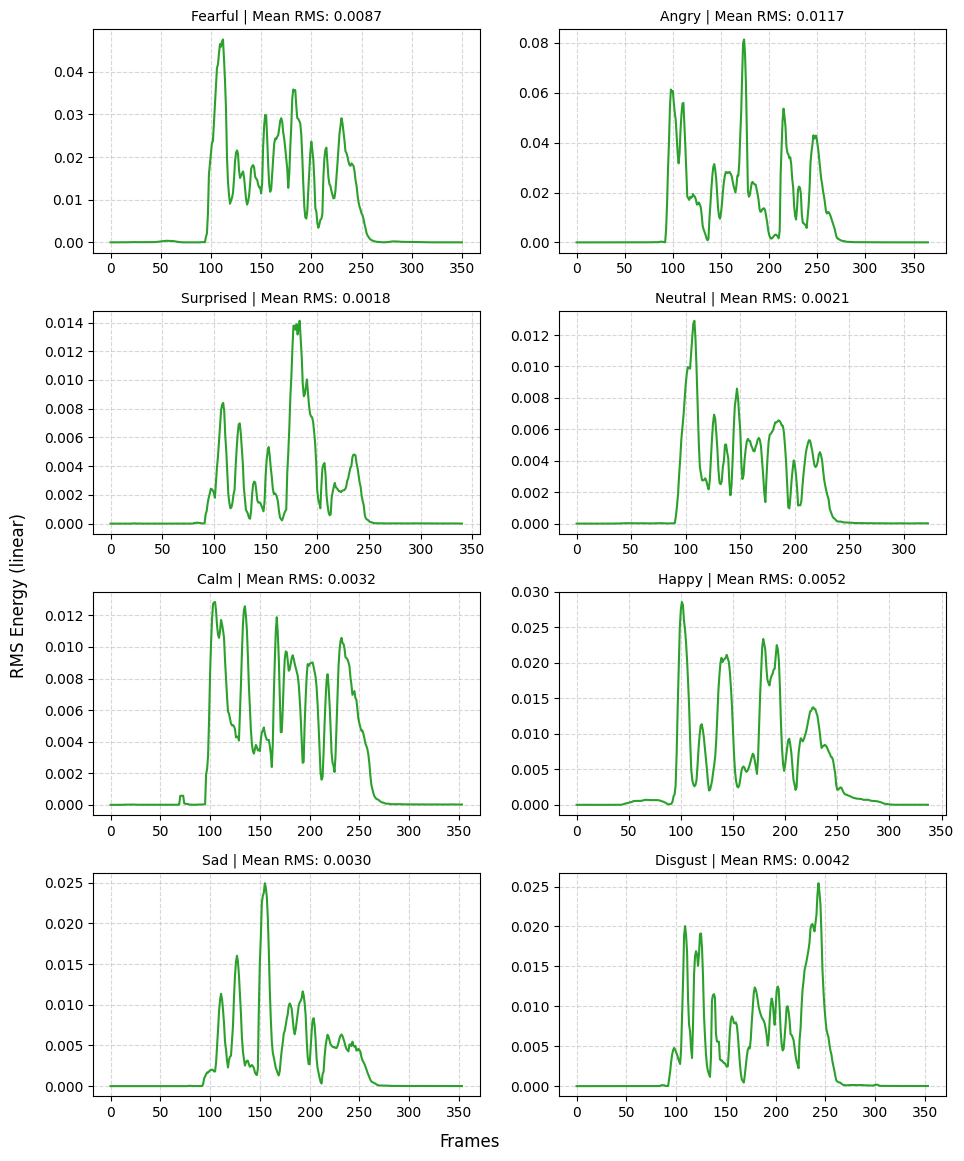

In [12]:
import matplotlib.pyplot as plt

# Grid layout
n_rows, n_cols = 4, 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axs = axs.flatten()

for i, row in rms_df.iterrows():
    # Plot linear RMS per frame
    axs[i].plot(row['rms_frames_linear'], color='tab:green')
    
    # Title with mean RMS (linear)
    axs[i].set_title(f"{row['emotion'].title()} | Mean RMS: {row['rms_frames_linear'].mean():.4f}", fontsize=10)
    
    axs[i].grid(True, linestyle='--', alpha=0.5)

# Shared axis labels
fig.text(0.5, 0.04, 'Frames', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'RMS Energy (linear)', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05,0.05,1,1])
plt.show()

---
### Rank by Loudness

From highest to lowest RMS:

- **Angry** → 0.0117 (highest)  
- **Fearful** → 0.0087  
- **Happy** → 0.0052  
- **Disgust** → 0.0042  
- **Calm** → 0.0032  
- **Sad** → 0.0030  
- **Neutral** → 0.0021  
- **Surprised** → 0.0018 (lowest)  

**Interpretation:**

- **Angry** and **Fearful** are the loudest emotions, which makes sense — people speak more forcefully or tensely when angry/fearful.  
- **Happy** and **Disgust** are moderate in loudness — happy often slightly louder, disgust can vary.  
- **Neutral, Calm, Sad** → low RMS — these are quieter, less energetic speech.  
- **Surprised** has very low RMS here, which might be due to the sample chosen (some surprised expressions are high-pitched but soft in volume).

---

In [13]:
rms_list = []

for file in metadata["file"]:
    y, sr = librosa.load(audio_dir / file, sr=None)
    rms = librosa.feature.rms(y=y)[0]
    
    rms_list.append(rms.mean())

metadata["rms_mean"] = rms_list

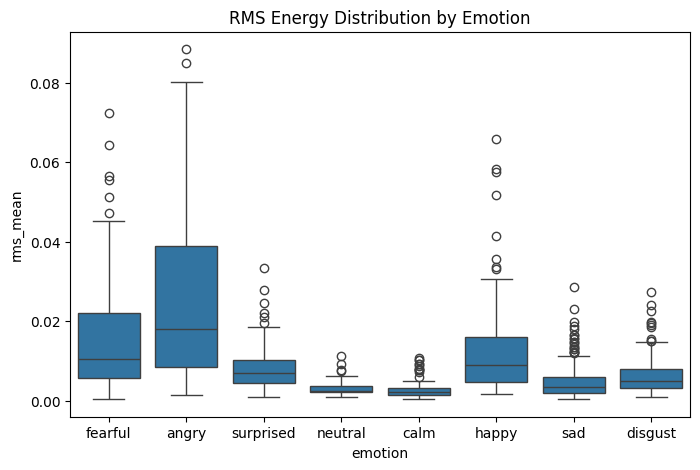

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=metadata, x="emotion", y="rms_mean")
plt.title("RMS Energy Distribution by Emotion")
plt.show()

### RMS Energy Analysis by Emotion

This boxplot shows the **distribution of per-sample RMS energy (`rms_mean`) for each emotion**. RMS energy reflects the **average loudness of each audio file**, and can serve as a feature for emotion recognition.

---

#### 1. Angry

* **Highest median RMS** among all emotions
* **Large spread across samples** (wide box + long whiskers)
* Several high outliers

**Interpretation:**
Samples labeled **angry** tend to be **louder and more variable** than other emotions in the dataset. RMS energy captures the strong vocal intensity typical of anger, though variability indicates some samples are quieter.

---

#### 2. Fearful and Happy

* Median RMS **higher than neutral or calm**, but lower than angry
* Moderate spread with occasional high outliers

**Interpretation:**

* **Fearful** speech can be tense, sometimes louder
* **Happy** speech is energetic and expressive
* Both show **dataset-level variation**, meaning some samples are louder than others

---

#### 3. Neutral and Calm

* **Lowest median RMS**
* Very tight spread among samples
* Few extreme values

**Interpretation:**
Samples labeled **neutral** or **calm** are consistently soft and controlled. RMS energy is effective at distinguishing these low-arousal emotions from high-arousal emotions like angry or happy.

---

#### 4. Surprised, Sad, Disgust

* Median RMS is **moderate**
* Spread is smaller than angry, but larger than calm/neutral

**Interpretation:**
These emotions are less consistently loud. For example:

* **Surprise** may include short bursts of louder speech
* **Sad** speech is mostly quiet but occasionally louder in some samples

---

#### 5. Variability and Feature Implications

* High-variance emotions: **angry, fearful, happy**
* Low-variance emotions: **calm, neutral**

**Interpretation:**

* RMS variation aligns with **arousal level**: high-arousal emotions tend to be louder and more variable across samples.
* RMS can help distinguish **high vs low arousal**, but is insufficient to separate overlapping emotions.

---

#### 6. Outliers

* Represent individual samples with unusually high RMS
* Could reflect speaker differences, recording conditions, or strong vocal emphasis

**Implication:**

* Outliers are normal; extreme values should be considered when **normalizing features** for ML.

---

#### TLDR

1. RMS energy per sample is a **one useful feature** for emotion recognition.
2. High-arousal emotions (angry, happy, fearful) have higher and more variable RMS values in the dataset.
3. Low-arousal emotions (calm, neutral) are softer and more consistent.
4. RMS alone **cannot fully distinguish all emotions** — combining with other features like **pitch, MFCCs, or spectral features** is recommended.

---


In [15]:
import librosa
import numpy as np
import pandas as pd

pitch_data = []

for emotion, file_name in sample_per_emotion.items():
    file_path = audio_dir / file_name
    y, sr = librosa.load(file_path, sr=None)
    
    # Extract fundamental frequency (pitch) using pyin
    f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=librosa.note_to_hz('C2'),
                                                 fmax=librosa.note_to_hz('C7'))
    pitch_mean = np.nanmean(f0)          # mean ignoring unvoiced frames
    pitch_std = np.nanstd(f0)
    
    pitch_data.append({
        'emotion': emotion,
        'pitch_mean': pitch_mean,
        'pitch_std': pitch_std,
        'f0_frames': f0
    })

pitch_df = pd.DataFrame(pitch_data)
pitch_df

,emotion,pitch_mean,pitch_std,f0_frames
0,fearful,279.502026,264.185816,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,angry,94.736102,23.170228,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,surprised,126.950435,41.158745,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,neutral,94.489119,14.293574,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,calm,91.224080,15.314602,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5,happy,268.841738,279.421479,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
6,sad,100.270726,19.074636,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
7,disgust,92.666339,24.021726,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


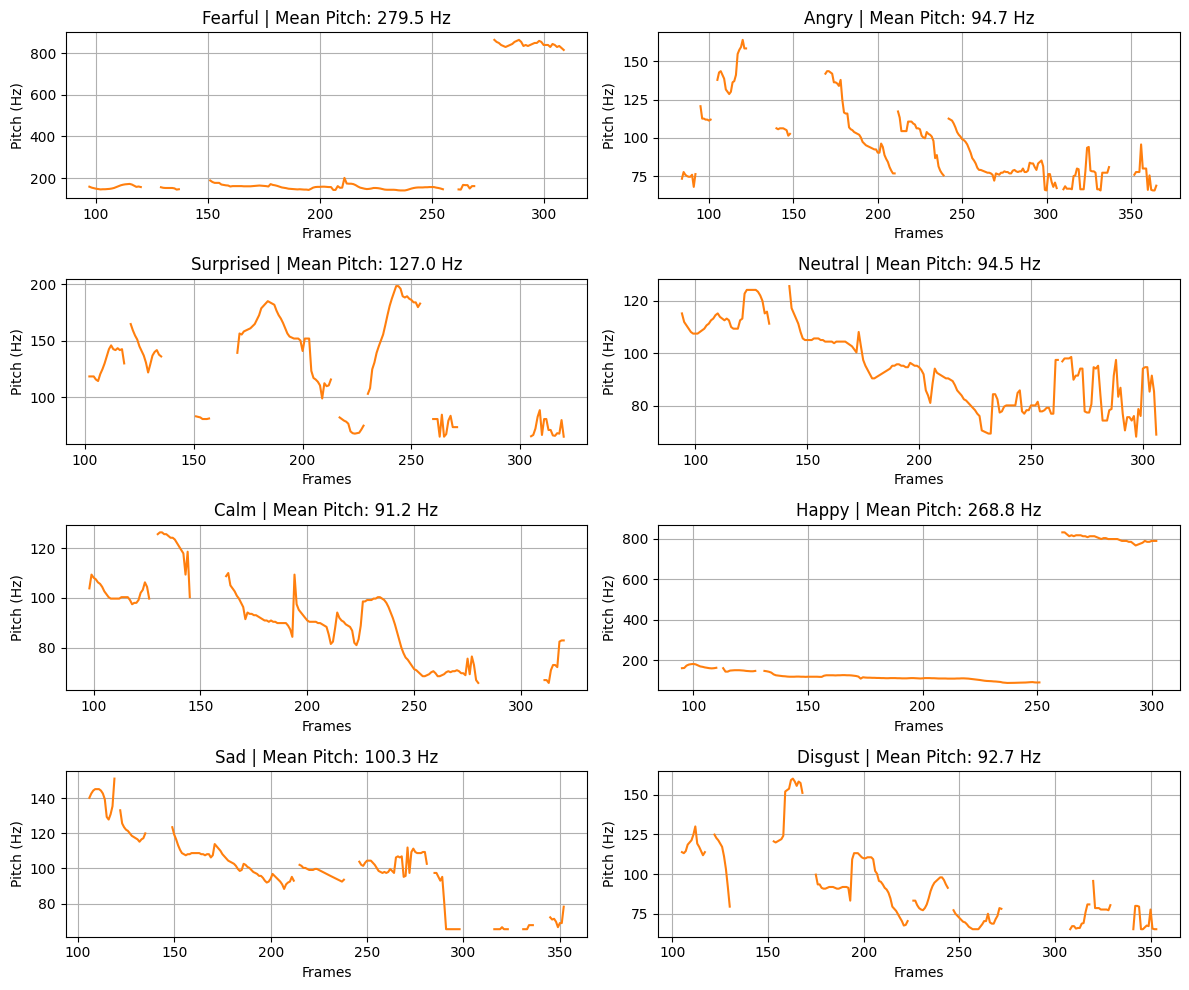

In [16]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 2, figsize=(12, 10))  # 4 rows x 2 cols
axs = axs.flatten()

for i, row in pitch_df.iterrows():
    axs[i].plot(row['f0_frames'], color='tab:orange')
    axs[i].set_title(f"{row['emotion'].title()} | Mean Pitch: {row['pitch_mean']:.1f} Hz")
    axs[i].set_xlabel("Frames")
    axs[i].set_ylabel("Pitch (Hz)")
    axs[i].grid(True)

plt.tight_layout()
plt.show()

## **Pitch Analysis (Fundamental Frequency, F0)**

**Mean pitch (Hz) per emotion:**

| Emotion   | Mean F0 (Hz) |
| --------- | ------------ |
| Fearful   | 279.5        |
| Angry     | 94.7         |
| Surprised | 127.0        |
| Neutral   | 94.5         |
| Calm      | 91.2         |
| Happy     | 268.8        |
| Sad       | 100.3        |
| Disgust   | 92.7         |

**Interpretation:**

* **High pitch:**

  * Fearful (279.5 Hz) and Happy (268.8 Hz) → consistent with excited, tense, or emotionally heightened speech.
* **Moderate pitch:**

  * Surprised (127 Hz) → short bursts of higher pitch, may vary across samples.
* **Low pitch:**

  * Angry (94.7 Hz), Neutral (94.5 Hz), Calm (91.2 Hz), Sad (100.3 Hz), Disgust (92.7 Hz) → more stable, controlled, or subdued speech.

**Insights:**

* Pitch can be a strong **indicator of emotional state**, especially for high-intensity emotions (fear, happiness).
* Low-intensity or negative emotions (calm, neutral, sad, disgust) tend to cluster in **lower pitch ranges**.
* Surprised has a moderate pitch here — may show **short high-pitched spikes** not captured by the mean alone.

---


In [20]:
pitch_std_list = []

for file in metadata["file"]:
    y, sr = librosa.load(audio_dir / file, sr=16000)
    
    f0 = librosa.yin(y, fmin=80, fmax=400)
    
    pitch_std_list.append(np.nanstd(f0))

metadata["pitch_std"] = pitch_std_list

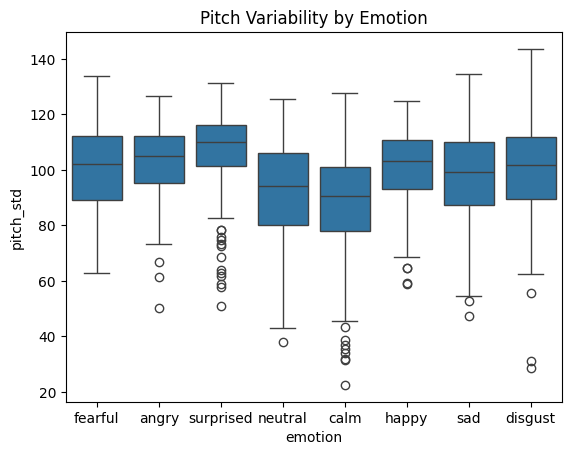

In [21]:
sns.boxplot(data=metadata, x="emotion", y="pitch_std")
plt.title("Pitch Variability by Emotion")
plt.show()

### **Pitch (F0) Analysis by Emotion**

This boxplot shows the **distribution of mean pitch (F0) per audio file** for each emotion. Each point is **one sample’s average pitch**, reflecting vocal tone. Pitch is informative for **emotion detection**, especially for separating emotions by **excitement**, because:

* High-pitched voices → high excitement (surprised, angry, happy)
* Low-pitched voices → low excitement (calm, neutral)

---

#### **1. High-Pitch / High-Excitement Emotions: Angry, Happy, Surprise**

* **Median pitch:** Surprise slightly higher than Angry ≈ Happy
* **Spread across samples:** Small (based on IQR)
* **Outliers:** Some unusually low-pitch samples (e.g., quieter expressions)

**Interpretation:**

* Samples in these emotions generally have **high average pitch**, making it easier for a model to distinguish them from low-excitement emotions.
* **Surprise** often includes **sudden vocal bursts (screeches)**, increasing mean pitch, explaining its high median.
* Pitch variability and outliers indicate **speaker differences**, so ML models should consider normalization or robust scaling.

---

#### **2. Medium-Pitch / Medium-Excitement Emotions: Disgust, Fearful, Sad**

* **Median pitch:** Slightly above low-pitch emotions but below high-pitch ones
* **Spread across samples:** Moderate (based on IQR)
* **Outliers:** Few low mean-pitch samples and no outlier for fearful

**Interpretation for ML:**

* These emotions are **moderate in vocal frequency**, so pitch alone is insufficient to fully separate them.
* ML models benefit from combining **mean pitch with RMS or spectral features** to resolve overlaps.
* Example: Fearful and Sad may have similar median pitch but differ in RMS variability, helping a classifier distinguish them.

---

#### **3. Low-Pitch / Low-Excitement Emotions: Neutral, Calm**

* **Median pitch:** Lowest among all emotions
* **Spread across samples:** Moderate (based on IQR)
* **Outliers:** Some unusually low mean-pitch samples especially calm

**Interpretation for ML:**

* Low-arousal emotions have **stable, low average pitch**, making them distinguishable from high-arousal emotions.
* Outliers should be handled carefully in preprocessing to prevent skewing features.
* Combined with RMS (low energy), these emotions are **easier for ML models to classify**.

---

#### **6. TLDR**

1. **Mean pitch per audio file is a strong feature for emotion detection**.
2. **High-pitch emotions (Angry, Happy, Surprise):** easier to separate from low-arousal emotions.
3. **Medium-pitch emotions (Disgust, Fearful, Sad):** overlaps exist; need complementary features.
4. **Low-pitch emotions (Neutral, Calm):** consistently low and stable; easier to classify.
5. **Pitch alone is insufficient** — combining with **RMS, MFCCs, spectral features, and temporal features** improves classification accuracy.
6. Outliers reflect natural variation and should be handled in ML pipelines via **normalization or clipping** to reduce feature noise.

---

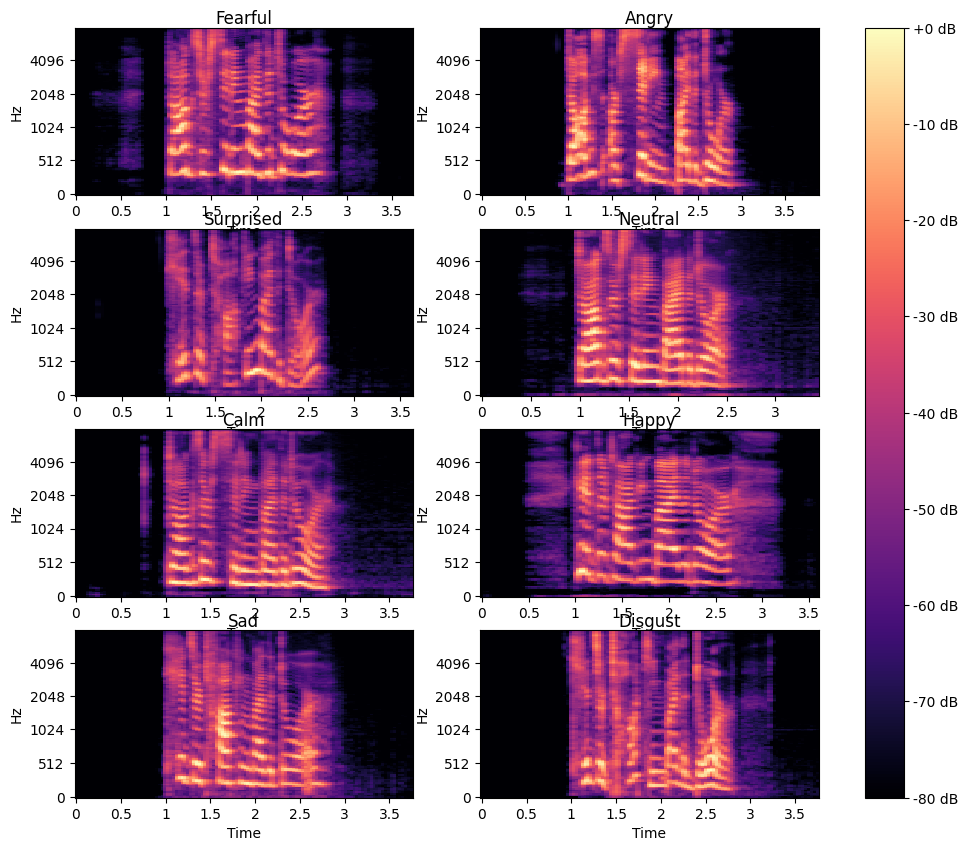

In [45]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i, (emotion, file_name) in enumerate(sample_per_emotion.items()):
    
    file_path = audio_dir / file_name
    y, sr = librosa.load(file_path, sr=16000)

    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis='time',
        y_axis='mel',
        ax=axs[i]
    )

    axs[i].set_title(emotion.title(), pad=3)

fig.colorbar(img, ax=axs, format="%+2.0f dB")
axs = axs.flatten()
plt.show()

## Analysis

- Distribution of energy across partial

This computes a Mel spectrogram, which represents:

- X-axis: time
- Y-axis: Mel-scaled frequencies
- Color: energy at that frequency

It shows where the sound energy exists in the frequency spectrum over time.

What it captures?
- Pitch patterns
- Harmonics
- Energy distribution
- Speech intensity

What you see visually?
- Bright areas → strong frequencies
- Dark areas → weak frequencies

This is very useful for visualizing speech structure.

---

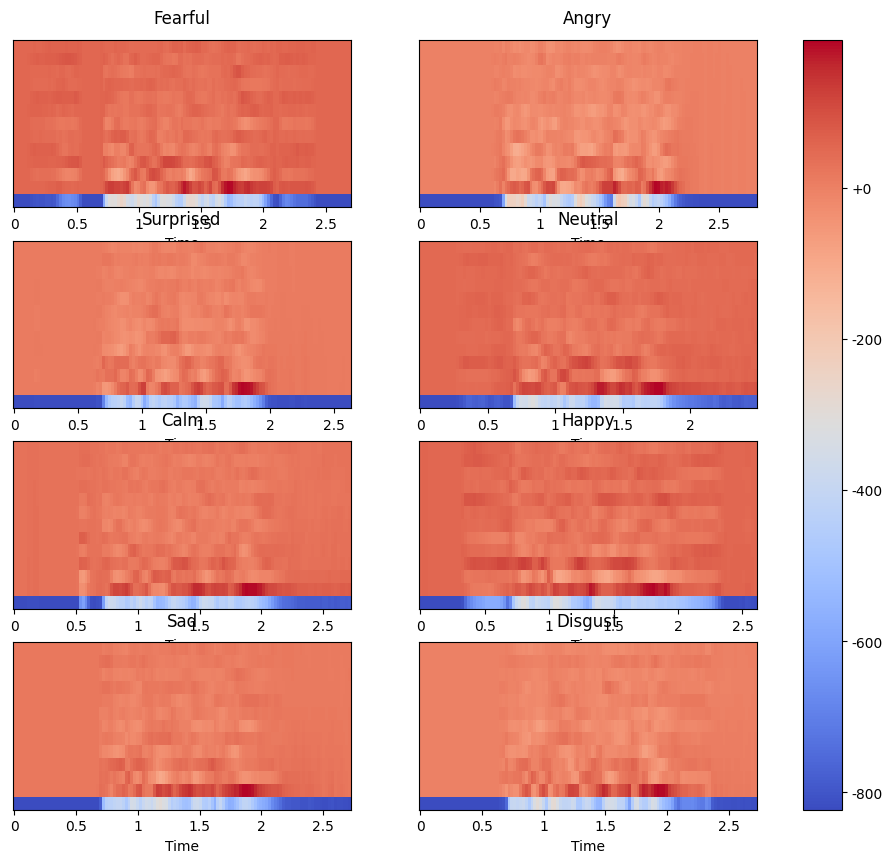

In [46]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i, (emotion, file_name) in enumerate(sample_per_emotion.items()):
    file_path = audio_dir / file_name
    y, sr = librosa.load(file_path, sr=16000)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    img = librosa.display.specshow(mfcc, x_axis='time', ax=axs[i])
    axs[i].set_title(emotion.title(), pad=12)

fig.colorbar(img, ax=axs, format="%+2.0f")
plt.show()

MFCCs are not frequencies. They are compressed features derived from the Mel spectrogram.

Pipeline conceptually:

Audio
  
   ↓

Mel Spectrogram
   
   ↓

Log energy
   
   ↓

DCT transform
   
   ↓

MFCC

- MFCC is basically a compact representation of the Mel spectrogram.

What MFCC captures?

- Speech timbre
- Vocal tract characteristics
- Spectral envelope

These are extremely useful for speech recognition and emotion detection.

In [ ]:
# Check audio formats, sample rates, channels (mono/stereo)

In [ ]:
# Histogram of audio durations → see if some classes are much longer/shorter.
# Decide on padding/truncation strategy.

In [ ]:
# Plot waveform for some samples.
# Look at amplitude distribution: are some clips very quiet or clipped?

In [ ]:
# Plot spectrograms, Mel-spectrograms, MFCCs.
# Observe patterns per emotion class.